# Evaluation: ground truth → metrics → CSV

## Where does the data live?
- **SRS document:** Expect a PDF such as `JDECo_SRS.docx[1].pdf` under **`data/srs/`** (or next to the workspace root per `resolve_default_srs_path`). That file is the **source of truth** whose text is chunked and indexed in FAISS.
- **Questions and reference answers:** Written **manually** in **`data/ground_truth/retrieval_ground_truth.json`**. Each item has a question, a short reference answer, and the linked filename (`srs_file` must match the **basename** used in the index, e.g. `JDECo_SRS.docx[1].pdf`).

## What this notebook does
1. Load questions from JSON.
2. Build a **FAISS vector index** per SRS file under `data/srs/` (same chunking settings as the rest of the project).
3. For each question: **retrieve top-K chunks**, then **generate an answer** with the LLM from those chunks only (RAG).
4. Compare the model answer to the **reference answer** using **cosine similarity** between **text embeddings** (same embedding model as indexing).
5. Compute **Hit@K**, the **fraction above a similarity threshold**, and **average similarity**.
6. Save CSVs and optionally plot a **histogram** of similarity scores.

## Why do the numbers look like that?
- **Semantic similarity** is not a claim-by-claim factual check; a **short** reference vs a **long** generated answer can score lower even when the meaning is right.
- **`GEN_THRESHOLD`** (e.g. 0.72) defines when an answer counts as “correct” in `gen_correct`.
- With **only one PDF** in the index, **Hit@K** often stays high because every chunk comes from the same file.

---

## Cell guide
Each **markdown cell below** immediately precedes the **code cell** it describes.



### Next code cell — install dependencies
**Why:** Ensure LangChain, FAISS, PyMuPDF, OpenAI, pandas, and matplotlib are available in the Jupyter environment.
**How:** `%pip install` installs or upgrades packages for the current kernel.



In [1]:
%pip install -q langchain-text-splitters langchain-core langchain-community langchain-openai faiss-cpu pymupdf openai python-dotenv pandas matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Next code cell — imports and package path
**Data:** Nothing loaded yet; this only sets `sys.path` to `rag_lab/src` so `qbrain_rag` imports work.
**Why:** The notebook runs from `notebooks/`, so the path is added manually unless you installed with `pip install -e .`.



In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

# Run this notebook from the notebooks/ folder (parent = rag_lab).
RAG_LAB = Path("..").resolve()
SRC = RAG_LAB / "src"
sys.path.insert(0, str(SRC))

from qbrain_rag.application.chunking import chunk_text
from qbrain_rag.application.evaluation import semantic_similarity
from qbrain_rag.infrastructure.vector_store import retrieve_top_k
from qbrain_rag.config.notebook_defaults import resolve_default_srs_path
from qbrain_rag.infrastructure.document_loaders import load_document
from qbrain_rag.infrastructure.llm import answer_with_context
from qbrain_rag.infrastructure.vector_store import build_faiss_store


### Next code cell — load ground truth and resolve SRS path
**Data:** **`retrieval_ground_truth.json`** (questions and **manually written** reference answers) and the primary PDF path from `data/srs/` (or the fallback search in `resolve_default_srs_path`).
**Output:** Variable `ground_truth` (a list), plus printing the SRS path and question ids.



In [2]:
SRS_DIR = RAG_LAB / "data" / "srs"
GT_PATH = RAG_LAB / "data" / "ground_truth" / "retrieval" / "retrieval_ground_truth.json"
PRIMARY_SRS = resolve_default_srs_path(RAG_LAB)

with open(GT_PATH, "r", encoding="utf-8-sig") as f:
    ground_truth = json.load(f)

print("Primary SRS:", PRIMARY_SRS)
len(ground_truth), [x["question_id"] for x in ground_truth]


Primary SRS: D:\Qbrainpython\QBrain\rag_lab\data\srs\JDECo_SRS.docx[1].pdf


(10,
 ['q_jdeco_01',
  'q_jdeco_02',
  'q_jdeco_03',
  'q_jdeco_04',
  'q_jdeco_05',
  'q_jdeco_06',
  'q_jdeco_07',
  'q_jdeco_08',
  'q_jdeco_09',
  'q_jdeco_10'])

### Next code cell — build FAISS indexes per SRS file
**Data:** Text extracted from each `.pdf`/`.txt` under **`data/srs/`** via `load_document`, then `chunk_text`, then `build_faiss_store`.
**Why:** Each JSON item points to `srs_file`; there must be an in-memory index whose key is that **filename**.



In [3]:
def build_store_for_file(path: Path):
    text = load_document(str(path))
    chunks = chunk_text(text)
    metas = []
    for i, c in enumerate(chunks):
        metas.append({"source_file": path.name, "chunk_id": i + 1})
    return build_faiss_store(chunks, metas)


paths: list[Path] = [PRIMARY_SRS]
seen = {p.resolve() for p in paths}
# Recursive: include nested folders (e.g. NL Requirements dataset unzipped under data/srs/)
_srs_extra: set[Path] = set()
for _pat in ("*.txt", "*.pdf", "*.html", "*.htm"):
    _srs_extra.update(SRS_DIR.rglob(_pat))
for p in sorted(_srs_extra, key=lambda x: str(x).lower()):
    if p.resolve() not in seen:
        paths.append(p)
        seen.add(p.resolve())

# Basenames must be unique across paths (ground_truth JSON uses file names only).
stores = {p.name: build_store_for_file(p) for p in paths}
list(stores.keys())


['JDECo_SRS.docx[1].pdf',
 '2007 - ertms.pdf',
 '2008 - keepass.pdf',
 '2009 - inventory 2.0.pdf',
 '2010 - gparted.pdf']

### Next code cell — main RAG evaluation loop (strict mode)
**Data:** Per item: question, reference answer from JSON, and the store for `srs_file`.
**Steps:** `retrieve_top_k` → `answer_with_context(..., temperature=0.1, evaluation_mode=True)` → `semantic_similarity(expected, generated)`.
**How results are formed:** Embedding cosine similarity between reference and generated text; `hit_file` is true if any basename from `relevant_files` appears in the top-K chunk metadata.



In [4]:
K = 5
GEN_THRESHOLD = 0.72
ANSWER_TEMPERATURE = 0.1


def unique_in_order(values):
    seen = set()
    out = []
    for v in values:
        if v and v not in seen:
            out.append(v)
            seen.add(v)
    return out


results = []
for item in ground_truth:
    fname = item["srs_file"]
    if fname not in stores:
        raise FileNotFoundError(f"Missing SRS index for: {fname}")

    store = stores[fname]
    q = item["question"]
    docs = retrieve_top_k(store, q, k=K)

    retrieved_files = unique_in_order([d.metadata.get("source_file") for d in docs])
    retrieved_chunk_ids = [d.metadata.get("chunk_id") for d in docs]

    answer = answer_with_context(
        q,
        docs,
        temperature=ANSWER_TEMPERATURE,
        evaluation_mode=True,
    )

    sim = semantic_similarity(item["expected_answer"], answer)
    relevant_files = item.get("relevant_files", [fname])

    results.append(
        {
            "question_id": item["question_id"],
            "question": q,
            "srs_file": fname,
            "relevant_files": ";".join(relevant_files),
            "retrieved_files_topk": ";".join(retrieved_files),
            "retrieved_chunk_ids": str(retrieved_chunk_ids),
            "hit_file": any(f in retrieved_files for f in relevant_files),
            "similarity": sim,
            "similarity_percent": sim * 100.0,
            "gen_correct": sim >= GEN_THRESHOLD,
            "generated_answer": answer,
            "expected_answer": item["expected_answer"],
        }
    )

results[:2]


[{'question_id': 'q_jdeco_01',
  'question': 'How can a customer submit a new service request in JDECo-SMS?',
  'srs_file': 'JDECo_SRS.docx[1].pdf',
  'relevant_files': 'JDECo_SRS.docx[1].pdf',
  'retrieved_files_topk': 'JDECo_SRS.docx[1].pdf',
  'retrieved_chunk_ids': '[14, 13, 21, 6, 16]',
  'hit_file': True,
  'similarity': 0.883423007104328,
  'similarity_percent': 88.3423007104328,
  'gen_correct': True,
  'generated_answer': 'The customer can request a service from JDECo-SMS by accessing it using a mobile application or JDECo portal.',
  'expected_answer': 'Customers can submit service requests through the JDECo-SMS mobile application or website, providing required details and supporting documents for the requested service.'},
 {'question_id': 'q_jdeco_02',
  'question': 'Who are the main user roles or departments involved in processing service requests?',
  'srs_file': 'JDECo_SRS.docx[1].pdf',
  'relevant_files': 'JDECo_SRS.docx[1].pdf',
  'retrieved_files_topk': 'JDECo_SRS.docx

### Next code cell — aggregate metrics
**Input:** List `results` from the previous step.
**Output:** Mean Hit@K, fraction of items above the similarity threshold (“answer accuracy”), and mean similarity — in a small `summary` DataFrame.



In [5]:
hit_at_k = sum(1 for r in results if r["hit_file"]) / len(results)
answer_accuracy = sum(1 for r in results if r["gen_correct"]) / len(results)
avg_sim = sum(r["similarity"] for r in results) / len(results)

summary = pd.DataFrame([
    {"metric": "Hit@5 (relevant file in top-k)", "value": hit_at_k},
    {"metric": f"Answer accuracy (sim ≥ {GEN_THRESHOLD})", "value": answer_accuracy},
    {"metric": "Average semantic similarity", "value": avg_sim},
])
summary


,metric,value
0,Hit@5 (relevant file in top-k),1.000000
1,Answer accuracy (sim ≥ 0.72),0.600000
2,Average semantic similarity,0.713838


### Next code cell — export CSVs
**Why:** Persist results for spreadsheets or a paper: `data/outputs/` and `results/tables/`.



In [7]:
out_dir = RAG_LAB / "data" / "outputs"
tables_dir = RAG_LAB / "results" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

df = pd.DataFrame(results)
df.to_csv(out_dir / "evaluation_results.csv", index=False)
summary.to_csv(out_dir / "summary_metrics.csv", index=False)

retrieval_cols = ["question_id", "srs_file", "hit_file", "relevant_files", "retrieved_files_topk"]
df[retrieval_cols].to_csv(tables_dir / "retrieval_table.csv", index=False)
df[["question_id", "similarity", "gen_correct", "expected_answer", "generated_answer"]].to_csv(
    tables_dir / "generation_table.csv", index=False
)
summary.to_csv(tables_dir / "evaluation_summary.csv", index=False)

print("Saved:", out_dir)
print("Tables:", tables_dir)


Saved: D:\Qbrainpython\QBrain\rag_lab\data\outputs
Tables: D:\Qbrainpython\QBrain\rag_lab\results\tables


### Next code cell — optional feature / testcase tables
**Data:** If present, `feature_ground_truth.json` or `testcases_ground_truth.json` under `data/ground_truth/`.
**Why:** Appendix tables for reports; if files are missing, nothing fails.



In [8]:
feat_path = RAG_LAB / "data" / "ground_truth" / "feature_ground_truth.json"
tc_path = RAG_LAB / "data" / "ground_truth" / "testcases_ground_truth.json"

if feat_path.is_file():
    with open(feat_path, "r", encoding="utf-8") as f:
        feat = json.load(f)
    rows = []
    for srs_name, items in feat.items():
        if srs_name == "description" or not isinstance(items, list):
            continue
        for it in items:
            rows.append({"srs_file": srs_name, **it})
    pd.DataFrame(rows).to_csv(tables_dir / "feature_table.csv", index=False)

if tc_path.is_file():
    with open(tc_path, "r", encoding="utf-8") as f:
        tc = json.load(f)
    pd.DataFrame(tc.get("features", [])).to_csv(tables_dir / "testcase_table.csv", index=False)

print("Feature/testcase tables updated (if JSON present).")


Feature/testcase tables updated (if JSON present).


### Next code cell — similarity histogram
**Data:** Column `similarity` from `df`.
**Output:** Figure `similarity_distribution.png` under `results/figures/` to see how scores spread across questions.



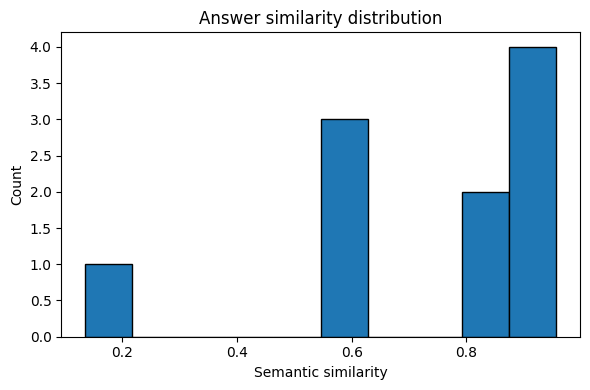

In [9]:
try:
    import matplotlib.pyplot as plt

    fig_dir = RAG_LAB / "results" / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6, 4))
    plt.hist(df["similarity"], bins=10, edgecolor="black")
    plt.xlabel("Semantic similarity")
    plt.ylabel("Count")
    plt.title("Answer similarity distribution")
    plt.tight_layout()
    plt.savefig(fig_dir / "similarity_distribution.png", dpi=150)
    plt.show()
except ImportError:
    print("Install matplotlib to save figures.")


## Note (section-level metrics)

This notebook does **not** compute **Precision / Recall at the `FR-*` section level**; that requires chunk metadata tagged with requirement IDs. If you maintain those spans elsewhere, use the dedicated evaluation track for section-level P@R.

